In [1]:
%matplotlib inline

import sys
import yaml
import copy

import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../../')
sys.path.append('../../../../')

%load_ext autoreload
%autoreload 2
    
from computer_vision.yolov11_pose.data.dataset import YOLODataset
from computer_vision.yolov11_pose.utils import DEFAULT_CFG_DICT
from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.misc import alpha_bending, instance2mask
from computer_vision.yolov11_pose.cfg import get_cfg

In [2]:
from matplotlib import patches
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

In [3]:
args=parser.parse_args('--deterministic'.split())

task='segment'
if task=='pose':
    data_dirpath='D:/data/ultralytics/coco8-pose'
    data_config='../../coco8-pose.yaml'
elif task=='detect':
    data_dirpath='D:/data/ultralytics/coco/images/train2017'
    data_config='../../coco.yaml'
elif task=='segment':
    data_dirpath='D:/data/ultralytics/coco8-seg'
    data_config='../../coco8-seg.yaml'
    
dataset=YOLODataset(args=args, data=data_config, task=task, img_path=data_dirpath, imgsz=640, cache=False,augment=True, 
                    hyp=DEFAULT_CFG_DICT, prefix='',rect=False,batch_size=16,stride=32,pad=0.5, single_cls=False,classes=None,
                fraction=1.,channels=3)
for i in range(4): print(dataset.labels[i]['cls'].shape)

hyp=get_cfg()

In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco8-seg\labels\train.cache
Scanning D:\data\ultralytics\coco8-seg\labels\train.cache... 8 images, 0 backgrounds, 0 corrupts
(8, 1)
(2, 1)
(2, 1)
(1, 1)


In [4]:
from __future__ import annotations

import math
import random
from copy import deepcopy
from typing import Any

import cv2
import numpy as np
import torch
from PIL import Image
from torch.nn import functional as F

from computer_vision.yolov11_pose.data.augment import BaseMixTransform, Mosaic, LetterBox, RandomPerspective, CopyPaste, RandomFlip, RandomHSV, \
Compose, Format, v8_transforms
from computer_vision.yolov11_pose.utils.instance import Instances
from computer_vision.yolov11_pose.utils.metrics import bbox_ioa
from computer_vision.yolov11_pose.utils.viz import general_skeleton_overlay

from computer_vision.yolov11_pose.data.utils import polygon2mask, polygon2masks_overlap, polygons2masks
from computer_vision.yolov11_pose.utils.ops import xywh2xyxy

In [5]:
mode='training'

if mode=='training':
    transforms=v8_transforms(dataset, hyp.imgsz, hyp)
else:
    transforms=Compose([LetterBox(new_shape=(hyp.imgsz, hyp.imgsz), scaleup=False)])

formatter= Format(
                bbox_format="xywh",
                normalize=True,
                return_mask=task=='segment',
                return_keypoint=task=='pose',
                return_obb=False,
                batch_idx=True,
                mask_ratio=hyp.mask_ratio,
                mask_overlap=hyp.overlap_mask,
                bgr=hyp.bgr if mode=='training' else 0.0,  # only affect training.
            )

In [6]:
indx=5
labels=dataset.get_image_and_label(indx) # main label
original_labels=copy.deepcopy(labels)
transformed_labels=transforms(labels)
formatted_labels=copy.deepcopy(transformed_labels)
formatted_labels=formatter(formatted_labels)

img  (478, 640, 3) height 478, width 640
masks.ndim!=img.ndim  False 3 3 (478, 640, 3) (478, 640, 3)
masks  (478, 640, 3)  img  (478, 640, 3)
img  (640, 640, 3) height 640, width 640
masks.ndim!=img.ndim  False 3 3 (640, 640, 3) (640, 640, 3)
masks  (640, 640, 3)  img  (640, 640, 3)
img  torch.Size([3, 640, 640]) height 640, width 640
masks.ndim!=img.ndim  False 3 3 (160, 160, 1) (640, 640, 3)
masks.ndim!=img.ndim  True
masks  (640, 640, 3)  img  (640, 640, 3)
masks  (640, 640, 3)  img  (640, 640, 3)


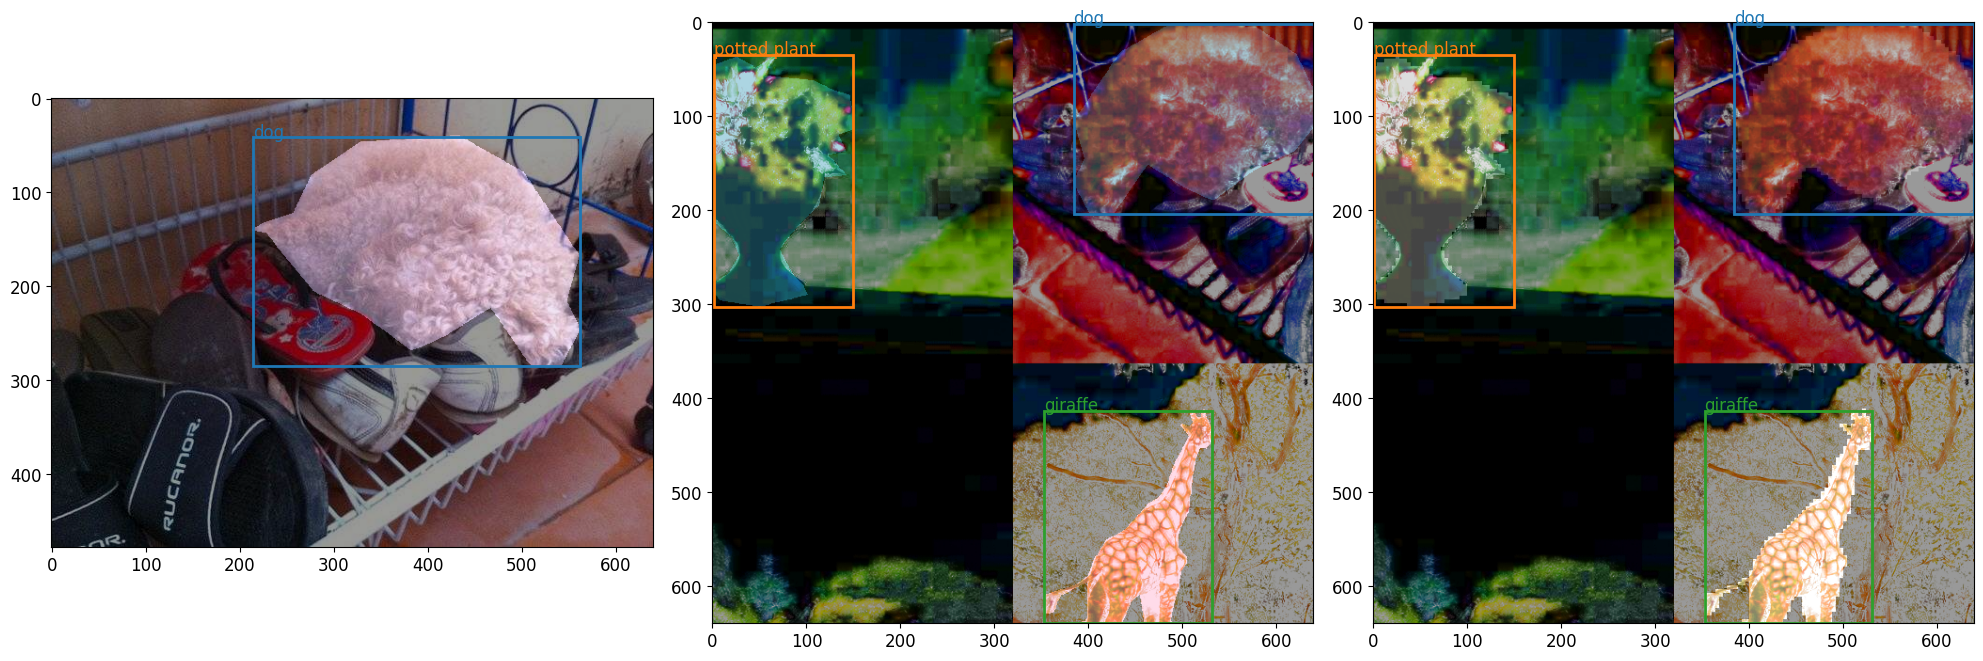

In [7]:
_, ax=plt.subplots(1,3,figsize=(20,8))
for i, labels in enumerate([original_labels, transformed_labels, formatted_labels]):
    classes=[dataset.data['names'][int(c)] for c in labels['cls'].flatten()] # *N,1) -> (N,)
    img=labels['img'] 
    height, width=img.shape[:2] if isinstance(img, np.ndarray) else img.shape[1:]
    print('img ', img.shape, f'height {height}, width {width}')
    if isinstance(img, torch.Tensor):
        img=img.permute(1,2,0).contiguous().numpy() # HxWxC
        img=img[:,:,::-1] # RGB to BGR
    # get boxes, keypoints, masks
    masks=None
    if 'instances' in labels:
        instances=copy.deepcopy(labels['instances'])
        if instances._bboxes.format=='xywh': instances.convert_bbox('xyxy')
        if instances.normalized: instances.denormalize(width, height)
        bboxes=instances.bboxes
        if hasattr(labels['instances'], 'segments') and len(getattr(labels['instances'], 'segments')):
            masks=instance2mask(image=img, instance=labels['instances']) # HxWxC
        keypoints=instances.keypoints
    else:
        # xywh to xyxy
        bboxes=labels['bboxes'].clone() # Nx4
        bboxes=xywh2xyxy(bboxes)
        # denormalize bboxes
        bboxes[...,[0,2]]*=width 
        bboxes[...,[1,3]]*=height
        bboxes=bboxes.numpy()
        if 'masks' in labels:
            masks=labels['masks'].clone() 
            if masks.shape[0]>1: masks=torch.argsort(masks, dim=0)
            masks=masks.permute(1,2,0).contiguous().numpy() # HxWxC
        keypoints=labels['keypoints'].clone() if 'keypoints' in labels else None # NxMx3
        if keypoints is not None: # denormalized
            keypoints[...,0]*=width
            keypoints[...,1]*=height
            keypoints=keypoints.numpy()
    if masks is not None:
        if masks.shape != img.shape:
            masks=cv2.resize(masks, (width, height), interpolation=cv2.INTER_NEAREST) # if mask is of shape HxWx1, cv2.resize give shape HxW
        if masks.ndim!=img.ndim:
            masks=np.repeat(masks[...,None], 3, axis=-1)
        ax[i].imshow(alpha_bending(masks, img[...,::-1], 0.4))
    elif keypoints is not None:
        img=general_skeleton_overlay(img_bgr=img, class_names=classes, bboxes=bboxes, keypoints=keypoints)
        ax[i].imshow(img[...,::-1])
    else: ax[i].imshow(img[...,::-1])
    if keypoints is None:
        for j, (box,cls) in enumerate(zip(bboxes, classes)):
            # Create a Rectangle patch
            rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
            # Add the patch to the Axes
            ax[i].add_patch(rect)
            ax[i].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)

plt.tight_layout()